In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("irfanahammad/wheather-dataset-15k-rows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'wheather-dataset-15k-rows' dataset.
Path to dataset files: /kaggle/input/wheather-dataset-15k-rows


In [ ]:
import os
print(os.listdir(path))

['.nfs000000009973489000000067', 'weather_classification_dataset.csv']


In [ ]:
df=pd.read_csv(path+'/weather_classification_dataset.csv')
df.head()

,Temperature,Humidity,WindSpeed,Pressure,Visibility,UVIndex,CloudCover,DewPoint,Season,DayType,LocationType,Weather
0,39.0,29.6,14.5,1011.4,19.7,8.3,16.0,6.0,Spring,Weekday,Coastal,Sunny
1,18.6,90.6,51.1,980.0,1.0,0.0,94.7,21.1,Winter,Weekday,Rural,Stormy
2,28.2,72.5,31.8,1004.3,5.5,1.1,77.7,16.1,Summer,Weekday,Mountain,Rainy
3,27.7,50.5,16.5,1004.1,13.3,7.3,72.0,21.6,Spring,Weekend,Mountain,Cloudy
4,42.0,20.0,8.6,1021.5,17.5,8.3,13.7,10.0,Summer,Weekday,Urban,Sunny


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Temperature   15000 non-null  float64
 1   Humidity      15000 non-null  float64
 2   WindSpeed     15000 non-null  float64
 3   Pressure      15000 non-null  float64
 4   Visibility    15000 non-null  float64
 5   UVIndex       15000 non-null  float64
 6   CloudCover    15000 non-null  float64
 7   DewPoint      15000 non-null  float64
 8   Season        15000 non-null  object 
 9   DayType       15000 non-null  object 
 10  LocationType  15000 non-null  object 
 11  Weather       15000 non-null  object 
dtypes: float64(8), object(4)
memory usage: 1.4+ MB


In [ ]:
encode=pd.get_dummies(df,drop_first=True)
encode.head()

,Temperature,Humidity,WindSpeed,Pressure,Visibility,UVIndex,CloudCover,DewPoint,Season_Spring,Season_Summer,Season_Winter,DayType_Weekend,LocationType_Mountain,LocationType_Rural,LocationType_Urban,Weather_Rainy,Weather_Stormy,Weather_Sunny
0,39.0,29.6,14.5,1011.4,19.7,8.3,16.0,6.0,True,False,False,False,False,False,False,False,False,True
1,18.6,90.6,51.1,980.0,1.0,0.0,94.7,21.1,False,False,True,False,False,True,False,False,True,False
2,28.2,72.5,31.8,1004.3,5.5,1.1,77.7,16.1,False,True,False,False,True,False,False,True,False,False
3,27.7,50.5,16.5,1004.1,13.3,7.3,72.0,21.6,True,False,False,True,True,False,False,False,False,False
4,42.0,20.0,8.6,1021.5,17.5,8.3,13.7,10.0,False,True,False,False,False,False,True,False,False,True


In [ ]:
encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Temperature            15000 non-null  float64
 1   Humidity               15000 non-null  float64
 2   WindSpeed              15000 non-null  float64
 3   Pressure               15000 non-null  float64
 4   Visibility             15000 non-null  float64
 5   UVIndex                15000 non-null  float64
 6   CloudCover             15000 non-null  float64
 7   DewPoint               15000 non-null  float64
 8   Season_Spring          15000 non-null  bool   
 9   Season_Summer          15000 non-null  bool   
 10  Season_Winter          15000 non-null  bool   
 11  DayType_Weekend        15000 non-null  bool   
 12  LocationType_Mountain  15000 non-null  bool   
 13  LocationType_Rural     15000 non-null  bool   
 14  LocationType_Urban     15000 non-null  bool   
 15  We

In [ ]:
X=encode.drop(["Weather_Rainy","Weather_Sunny","Weather_Stormy"],axis=1)

In [ ]:
y=df["Weather"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(X_train,y_train)

GaussianNB()

In [ ]:
y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9766666666666667
[[ 711   34    0    0]
 [  30  696    2    0]
 [   0    4  296    0]
 [   0    0    0 1227]]
              precision    recall  f1-score   support

      Cloudy       0.96      0.95      0.96       745
       Rainy       0.95      0.96      0.95       728
      Stormy       0.99      0.99      0.99       300
       Sunny       1.00      1.00      1.00      1227

    accuracy                           0.98      3000
   macro avg       0.98      0.97      0.97      3000
weighted avg       0.98      0.98      0.98      3000



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Temperature   15000 non-null  float64
 1   Humidity      15000 non-null  float64
 2   WindSpeed     15000 non-null  float64
 3   Pressure      15000 non-null  float64
 4   Visibility    15000 non-null  float64
 5   UVIndex       15000 non-null  float64
 6   CloudCover    15000 non-null  float64
 7   DewPoint      15000 non-null  float64
 8   Season        15000 non-null  object 
 9   DayType       15000 non-null  object 
 10  LocationType  15000 non-null  object 
 11  Weather       15000 non-null  object 
dtypes: float64(8), object(4)
memory usage: 1.4+ MB


In [ ]:
df.isna().sum()

,0
Temperature,0
Humidity,0
WindSpeed,0
Pressure,0
Visibility,0
UVIndex,0
CloudCover,0
DewPoint,0
Season,0
DayType,0


<Axes: >

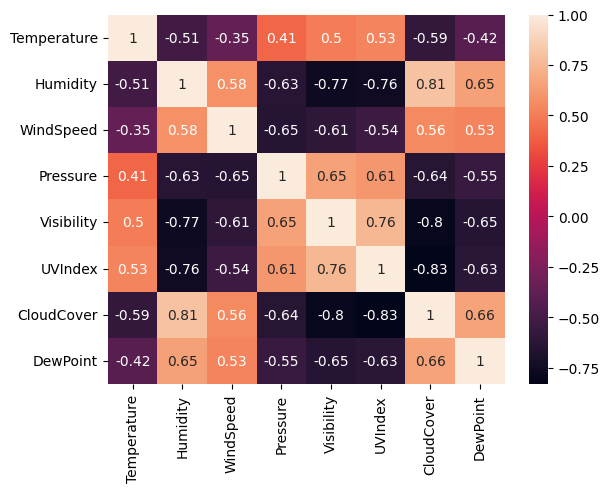

In [ ]:

sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Weather', ylabel='Count'>

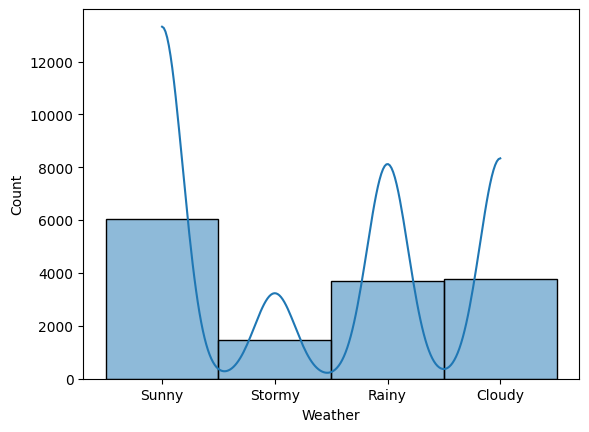

In [ ]:
sns.histplot(df["Weather"],kde=True)

<Axes: xlabel='Weather', ylabel='count'>

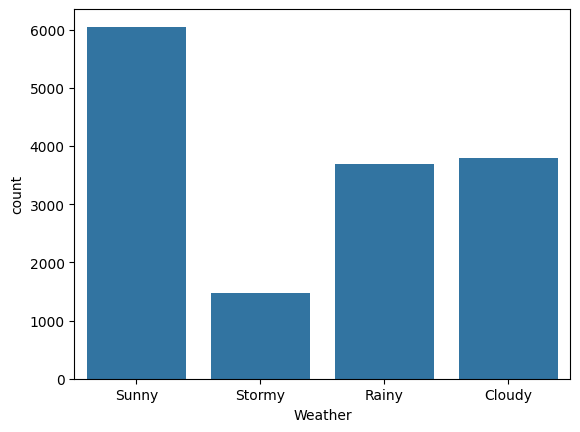

In [ ]:
sns.countplot(x="Weather",data=df)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Temperature   15000 non-null  float64
 1   Humidity      15000 non-null  float64
 2   WindSpeed     15000 non-null  float64
 3   Pressure      15000 non-null  float64
 4   Visibility    15000 non-null  float64
 5   UVIndex       15000 non-null  float64
 6   CloudCover    15000 non-null  float64
 7   DewPoint      15000 non-null  float64
 8   Season        15000 non-null  object 
 9   DayType       15000 non-null  object 
 10  LocationType  15000 non-null  object 
 11  Weather       15000 non-null  object 
dtypes: float64(8), object(4)
memory usage: 1.4+ MB


In [ ]:
corr=df.corr(numeric_only=True)["Weather"]

KeyError: 'Weather'